# Toy Model: 核小体在DNA上的动态模拟

**假设：**
- DNA 长度 2000 bp，上面放置 9 个核小体（每个 147 bp）
- 参数只有两个：运动速度 `v` 和最小核小体间距 `d`
- 初始随机放置，相邻间距 ≥ d
- 每步各核小体随机选择方向（各 50%），以速度 v 移动
- 若移动导致间距 < d，立即反向（尝试另一方向）；两端碰到 DNA 边界也反弹

**核心问题：** 体系最终是否会演化到所有核小体间距均等的状态？

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import clear_output
import matplotlib

matplotlib.rcParams['font.size'] = 11
np.random.seed(42)

## 1. 参数设置

In [ ]:
# ========== 可调参数 ==========
L = 2000          # DNA 长度 (bp)
N = 9             # 核小体数量
L_NUC = 147       # 每个核小体长度 (bp)
v = 5              # 运动速度 (bp/步)
d = 40            # 最小核小体间距 (bp)
N_STEPS = 5000    # 模拟步数

# ========== 衍生量 ==========
TOTAL_NUC_BP = N * L_NUC               # 核小体占据的总 bp
FREE_SPACE = L - TOTAL_NUC_BP           # 剩余可用空间
MIN_GAP_SUM = (N - 1) * d               # 最小间距总和
EQUAL_GAP = FREE_SPACE / (N - 1)        # 均等间距的理论值

print(f'DNA 长度: {L} bp')
print(f'核小体: {N} × {L_NUC} bp = {TOTAL_NUC_BP} bp')
print(f'剩余空间: {FREE_SPACE} bp')
print(f'理论均等间距: {EQUAL_GAP:.1f} bp')
print(f'最小间距约束 d = {d} bp')
print(f'速度 v = {v} bp/步')
print(f'模拟步数: {N_STEPS}')

assert FREE_SPACE >= MIN_GAP_SUM, (
    f'无法在 {L} bp 上放置 {N} 个核小体且间距 ≥ {d}！'
    f'至少需要 {TOTAL_NUC_BP + MIN_GAP_SUM} bp'
)

DNA 长度: 2000 bp
核小体: 9 × 147 bp = 1323 bp
剩余空间: 677 bp
理论均等间距: 84.6 bp
最小间距约束 d = 40 bp
速度 v = 10 bp/步
模拟步数: 50000


## 2. 初始化：随机放置核小体（间距 ≥ d）

In [13]:
def init_positions(L, N, l_nuc, d, rng):
    """
    逐个放置核小体，确保相邻间距 ≥ d 且全部在 [0, L) 内。
    
    对第 i 个核小体：
    - min_pos = 上一个核小体的末端 + d
    - max_pos = L - l_nuc - (剩余核小体数 × (l_nuc + d))
    在 [min_pos, max_pos] 中均匀随机采样。
    """
    positions = np.zeros(N)
    for i in range(N):
        if i == 0:
            min_pos = 0.0
        else:
            min_pos = positions[i - 1] + l_nuc + d
        
        remaining = N - i - 1  # 当前核小体之后还有几个
        max_pos = L - l_nuc - remaining * (l_nuc + d)
        positions[i] = rng.uniform(min_pos, max_pos)
    return positions


rng = np.random.default_rng(42)
pos = init_positions(L, N, L_NUC, d, rng)
gaps = pos[1:] - (pos[:-1] + L_NUC)

print(f'初始位置: {pos}')
print(f'初始间距: {gaps}')
print(f'初始间距 std: {gaps.std():.2f} bp')

初始位置: [ 276.30230933  498.71878591  724.59714214  916.06229051 1103.24477885
 1291.95721184 1478.98977961 1665.99781349 1852.99809361]
初始间距: [75.41647657 78.87835623 44.46514837 40.18248834 41.71243299 40.03256777
 40.00803389 40.00028012]
初始间距 std: 15.71 bp


## 3. 模拟：单步更新逻辑

In [14]:
def simulation_step(positions, L, N, l_nuc, v, d, rng):
    """
    单步模拟。随机打乱核小体顺序，逐个更新：
    1. 随机选方向 (+1 或 -1)
    2. 尝试移动 v bp
    3. 检查边界 + 与邻居间距
    4. 若违反约束，反向再试一次
    5. 仍不行则原地不动
    """
    order = rng.permutation(N)
    
    for i in order:
        direction = 1 if rng.random() < 0.5 else -1
        
        for attempt in range(2):
            proposed = positions[i] + direction * v
            proposed = max(0.0, min(proposed, L - l_nuc))  # 边界裁剪
            
            valid = True
            if i > 0 and proposed - (positions[i - 1] + l_nuc) < d:
                valid = False
            if i < N - 1 and positions[i + 1] - (proposed + l_nuc) < d:
                valid = False
            
            if valid:
                positions[i] = proposed
                break
            else:
                direction = -direction  # 反向
    
    return positions


def run_simulation(pos_init, L, N, l_nuc, v, d, n_steps, rng):
    """运行完整模拟，记录历史。"""
    pos = pos_init.copy()
    history = [pos.copy()]
    for step in range(n_steps):
        pos = simulation_step(pos, L, N, l_nuc, v, d, rng)
        history.append(pos.copy())
    return np.array(history)

In [15]:
print(f'运行模拟（{N_STEPS} 步）...')
rng_sim = np.random.default_rng(43)
history = run_simulation(pos, L, N, L_NUC, v, d, N_STEPS, rng_sim)
print(f'完成。history shape: {history.shape}')  # (N_STEPS+1, N)

运行模拟（50000 步）...
完成。history shape: (50001, 9)


In [16]:
# 提取间距
all_gaps = np.array([h[1:] - (h[:-1] + L_NUC) for h in history])  # (T, N-1)
gap_std = all_gaps.std(axis=1)

print(f'最终位置: {history[-1]}')
print(f'最终间距: {all_gaps[-1]}')
print(f'最终间距均值: {all_gaps[-1].mean():.2f} bp  (理论均等: {EQUAL_GAP:.1f} bp)')
print(f'最终间距 std:  {all_gaps[-1].std():.2f} bp')
print(f'初始间距 std:  {all_gaps[0].std():.2f} bp')

最终位置: [   0.          198.71878591  454.59714214  756.06229051  983.24477885
 1251.95721184 1448.98977961 1635.99781349 1853.        ]
最终间距: [ 51.71878591 108.87835623 154.46514837  80.18248834 121.71243299
  50.03256777  40.00803389  70.00218651]
最终间距均值: 84.62 bp  (理论均等: 84.6 bp)
最终间距 std:  37.66 bp
初始间距 std:  15.71 bp


## 4. 可视化

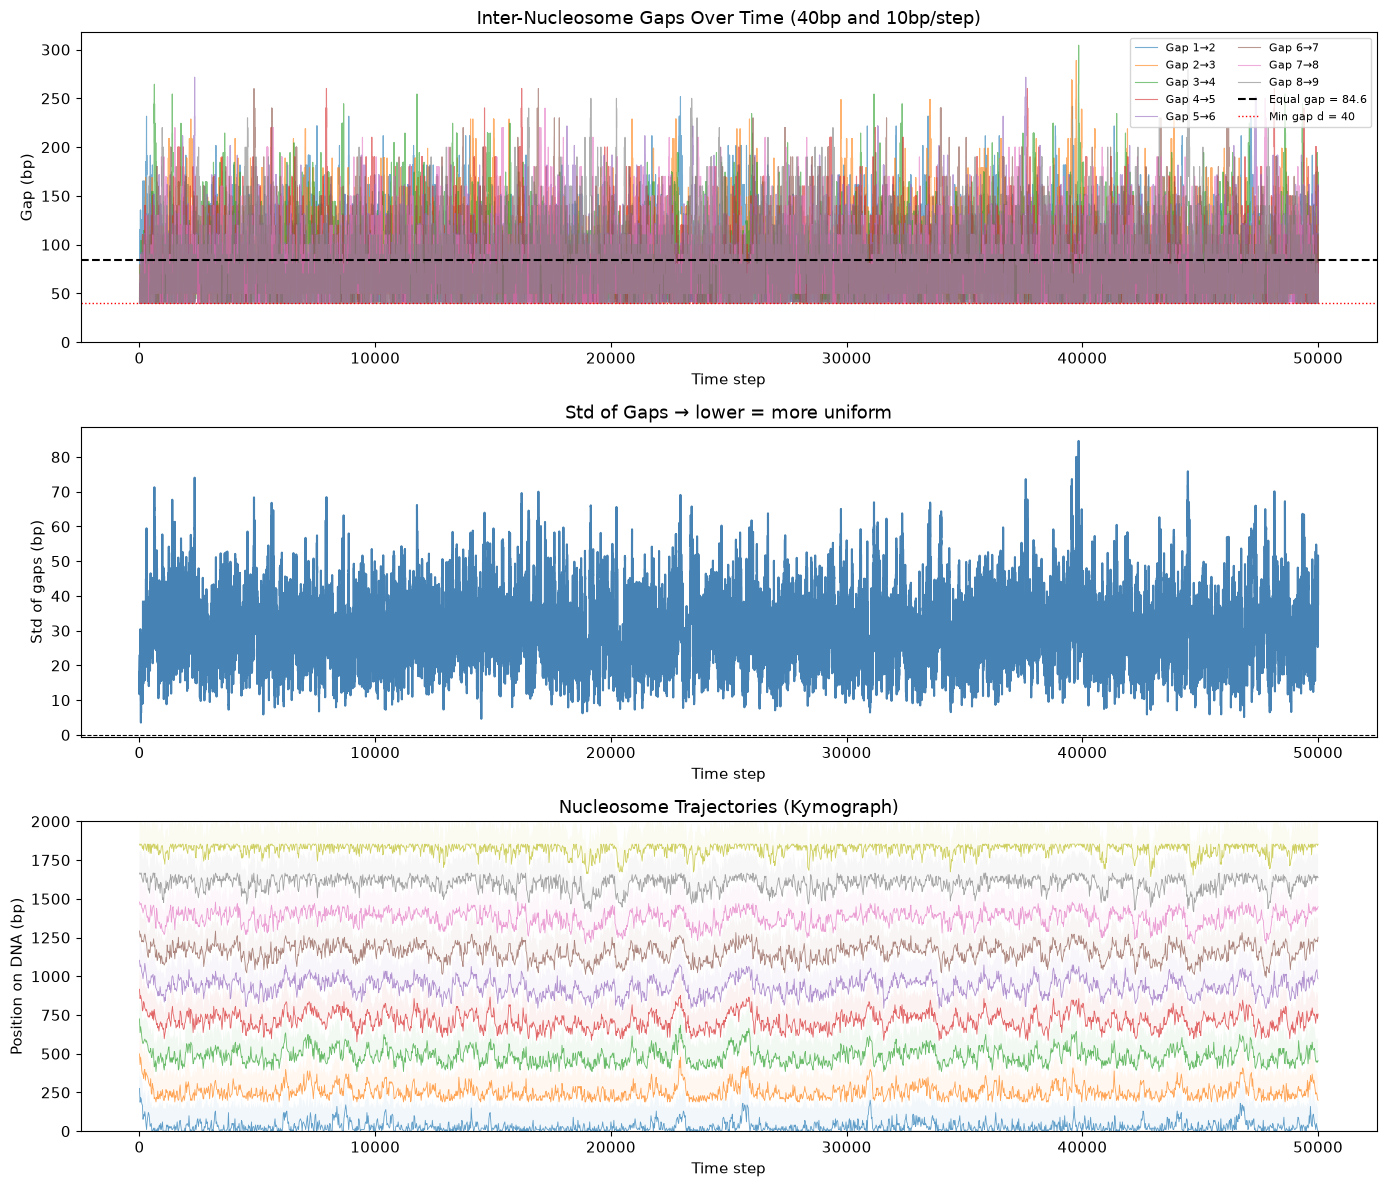

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# ---------- Panel 1: 间距随时间变化 ----------
ax1 = axes[0]
for i in range(N - 1):
    ax1.plot(all_gaps[:, i], alpha=0.6, lw=0.8, label=f'Gap {i+1}→{i+2}')
ax1.axhline(EQUAL_GAP, color='black', ls='--', lw=1.5, label=f'Equal gap = {EQUAL_GAP:.1f}')
ax1.axhline(d, color='red', ls=':', lw=1, label=f'Min gap d = {d}')
ax1.set_xlabel('Time step')
ax1.set_ylabel('Gap (bp)')
ax1.set_title(f'Inter-Nucleosome Gaps Over Time ({d}bp and {v}bp/step)')
ax1.legend(loc='upper right', fontsize=8, ncol=2)
ax1.set_ylim(bottom=0)

# ---------- Panel 2: 间距标准差（收敛指标）----------
ax2 = axes[1]
ax2.plot(gap_std, color='steelblue', lw=1.5)
ax2.axhline(0, color='black', ls='--', lw=0.8)
ax2.set_xlabel('Time step')
ax2.set_ylabel('Std of gaps (bp)')
ax2.set_title('Std of Gaps → lower = more uniform')

# ---------- Panel 3: Kymograph（轨迹图）----------
ax3 = axes[2]
# 若步数太多，降采样
plot_steps = min(len(history), 2000)
stride = max(1, len(history) // plot_steps)

for i in range(N):
    traj = history[::stride, i]
    t_axis = np.arange(0, len(history), stride)
    ax3.plot(t_axis, traj, lw=0.6, alpha=0.7)
    ax3.fill_between(t_axis, traj, traj + L_NUC, alpha=0.06)

ax3.set_xlabel('Time step')
ax3.set_ylabel('Position on DNA (bp)')
ax3.set_title('Nucleosome Trajectories (Kymograph)')
ax3.set_ylim(0, L)

plt.tight_layout()
plt.show()

## 5. 初始 vs 最终构型对比

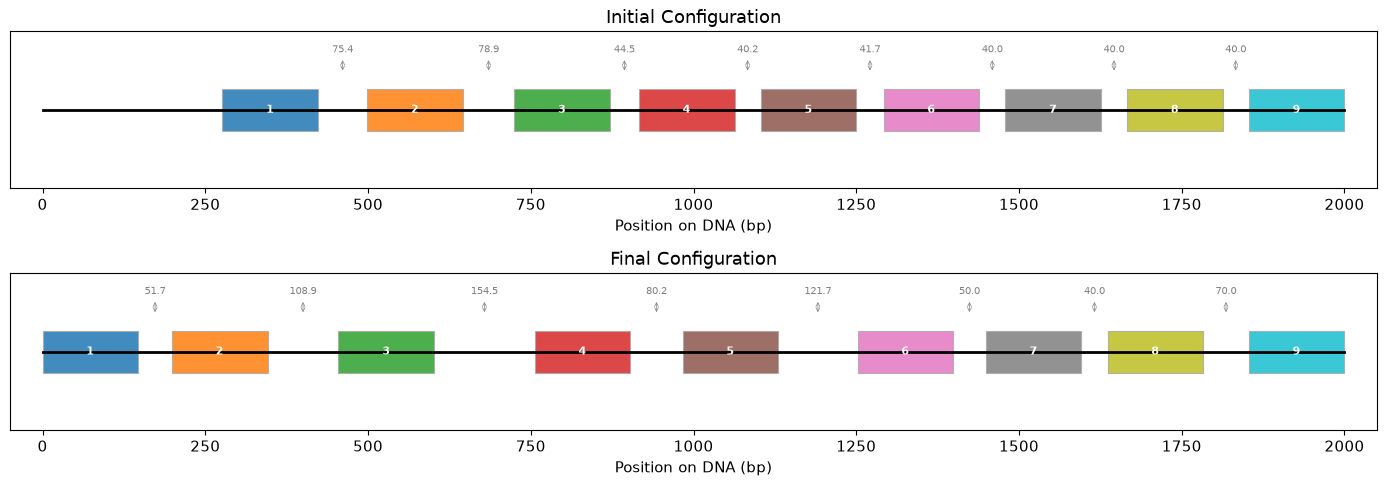

In [18]:
fig2, (ax_a, ax_b) = plt.subplots(2, 1, figsize=(14, 5))

colors = plt.cm.tab10(np.linspace(0, 1, N))

for ax, h, title in [(ax_a, history[0], 'Initial'), (ax_b, history[-1], 'Final')]:
    ax.plot([0, L], [0, 0], 'k-', lw=2)  # DNA
    ax.set_xlim(-50, L + 50)
    ax.set_ylim(-1.5, 1.5)
    ax.set_yticks([])
    ax.set_xlabel('Position on DNA (bp)')
    ax.set_title(f'{title} Configuration')

    for i, (p, c) in enumerate(zip(h, colors)):
        rect = Rectangle((p, -0.4), L_NUC, 0.8,
                          facecolor=c, edgecolor='darkgray', lw=0.8, alpha=0.85)
        ax.add_patch(rect)
        ax.text(p + L_NUC / 2, 0, str(i + 1), ha='center', va='center',
                fontsize=8, fontweight='bold', color='white')

    # 标注间距
    for i in range(N - 1):
        gap_start = h[i] + L_NUC
        gap_end = h[i + 1]
        gap_mid = (gap_start + gap_end) / 2
        ax.annotate(f'{gap_end - gap_start:.1f}',
                    xy=(gap_mid, 0.7), ha='center', fontsize=7, color='gray',
                    arrowprops=dict(arrowstyle='<->', color='gray', lw=0.5),
                    xytext=(gap_mid, 1.1))

plt.tight_layout()
plt.show()

## 6. 小结

- 从 Panel 1 看：各间距是否向 `EQUAL_GAP`（虚线）汇聚？
- 从 Panel 2 看：间距的标准差是否随时间下降？若下降 → 系统在自发趋向均等排列
- 从 Panel 3（Kymograph）看：核小体轨迹是否逐渐形成规则间距？
- 如果间距持续波动不收敛 → 仅靠 v, d 两个参数不足以产生有序排列，需要引入额外机制（如边界约束、能量函数等）